## IN_DATA
- `dat_minimap_traj`

## OUT_DATA
- `idx_masked_map_{job_id}`

## VERSION

## PACKAGE

In [1]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

## JOBS

In [2]:
# job_dict = get_job_dict_for_lossless_map_enum()
# len(job_dict)

In [3]:
# job_dict

## BASH PARAMETERS

In [4]:
# 38 enum_maps = 2 trajectories x 19 PIs
job_id = 5#int(sys.argv[1])

In [5]:
mouse_id = 3

In [6]:
# tag = f"mouse_{mouse_id}"
in_dir = project_dir / "results"
out_dir = in_dir / "data_maps"
#
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

## LOCAL PARAMETERS

In [7]:
n_cand_per_iter = 20
n_failures_to_stop = 10
n_maps = 100

## LOAD

In [8]:
# load df
# df_raw = pickle.load(open(in_dir / "df_raw", "rb"))
# df_equal = pickle.load(open(in_dir / "df_equal", "rb"))

# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## RUN SINGLE: eval on one (traj, pi, map)

In [9]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict)
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

In [67]:
# load traj
s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(1, 3, 0)]
# s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(0, 3, -1)]
# s_traj = np.array([37,50,63,76,89,102,115,127,128,129,130,131])
# a_traj = np.array([-1,1,1,1,1,1,1,1,0,0,0,0])

# load pi
idx_pi = 90
pi = pi_all[idx_pi]
sap_arr = get_sap_arr(pi_all[100], sas_dict, ringsize, n_tiles) # pq_prop_v1

# load map
np.random.seed(42)
map = np.random.permutation(n_edges)[:30]

# prep: pq_mask from map
# pq_mask_dict = get_pq_mask_dict_for_one_map(map, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges)
s_pq_mask_dict = get_s_pq_mask_dict_for_one_map(map, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)

In [68]:
# pq_prop
pq_traj = pq_prop_for_n_steps(s_traj, a_traj, T_dict, pi, s_pq_mask_dict, n_tiles, ringsize, sh_dz_arr)
score_map, score = get_score_map(s_traj, pq_traj.sum(-1), s_top)

# pq_prop_v1
# p_traj, q_traj = pq_prop_for_n_steps_v1(s_traj, a_traj, sap_arr, pi, pq_mask_dict, n_tiles, ringsize, sh_dz_arr)

# print
score

0.8318019290459837

In [ ]:
count, _ = np.histogram(s_traj, bins=np.arange(n_tiles+1))


In [33]:
(count/np.sum(count))[s_top].sum()

0.7534146213825944

In [74]:
set0 = set(s_top)

In [92]:
t = 10000
count_1 = np.histogram(s_traj[t:t+len(s_traj)//10], bins=np.arange(n_tiles+1))[0]
set1 = set(np.argsort(count_1/np.sum(count_1))[::-1][:77])
len(set0.intersection(set1))

69

In [82]:
p0 = np.histogram(s_traj, bins=np.arange(n_tiles+1), density=True)[0]

In [93]:
t = 10000
p1 = np.histogram(s_traj[t:t+len(s_traj)//10], bins=np.arange(n_tiles+1), density=True)[0]

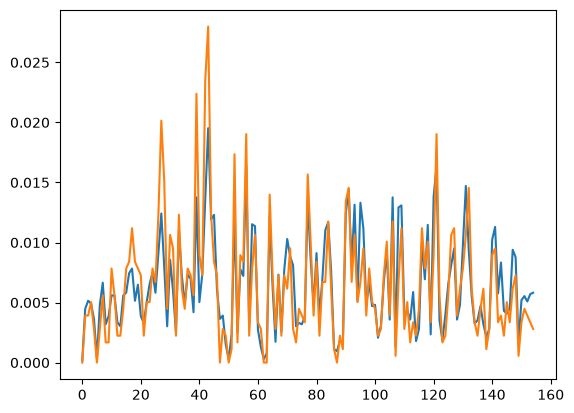

In [94]:
plt.plot(p0)
plt.plot(p1)

In [19]:
count

array([ 35, 167, 299, 270, 224, 186, 101,  86,  62,  77,  98, 126, 180,
        48, 151,  53,  29,  93,  94, 124, 151, 211, 112,  86, 142,  94,
        73,  95,  95,  20,  49,  47,  67, 129,  87, 137, 173,  86, 115,
        81,  16,  59,  38,  71, 118, 106,  40, 119, 111, 135,  37,  33,
        29,  57,   9,  37, 124, 138,  54, 160,  47, 175,  53,  52,  31,
        71,  12,   7, 131, 107,  88, 157,  53, 103, 180, 102, 253, 242,
       187,  45,  76, 144, 152,   4, 190,  90, 121, 239, 271,  83, 163,
       202, 244, 264, 138,  86, 229, 242, 249,  49, 155,  85,  34,  55,
        97, 164, 144, 107,   0, 261, 135, 265, 272, 164, 131, 147, 142,
        63, 117, 116,   0, 242,  43, 165,  72,  58, 282, 241, 153, 113,
       111,   0, 226, 266, 112, 133, 334, 396, 177,  81,  92,   0, 212,
        45, 223, 223,  48,  67,  53, 165, 199, 259, 199,  89,   0])

TypeError: float() argument must be a string or a real number, not 'Counter'

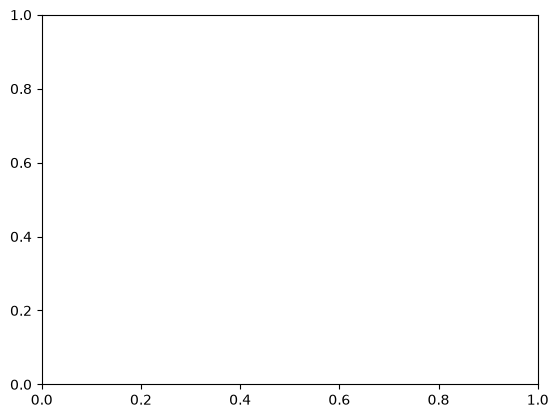

In [13]:
plt.plot(Counter(s_traj))

## TEST SINGLE

### pq_traj

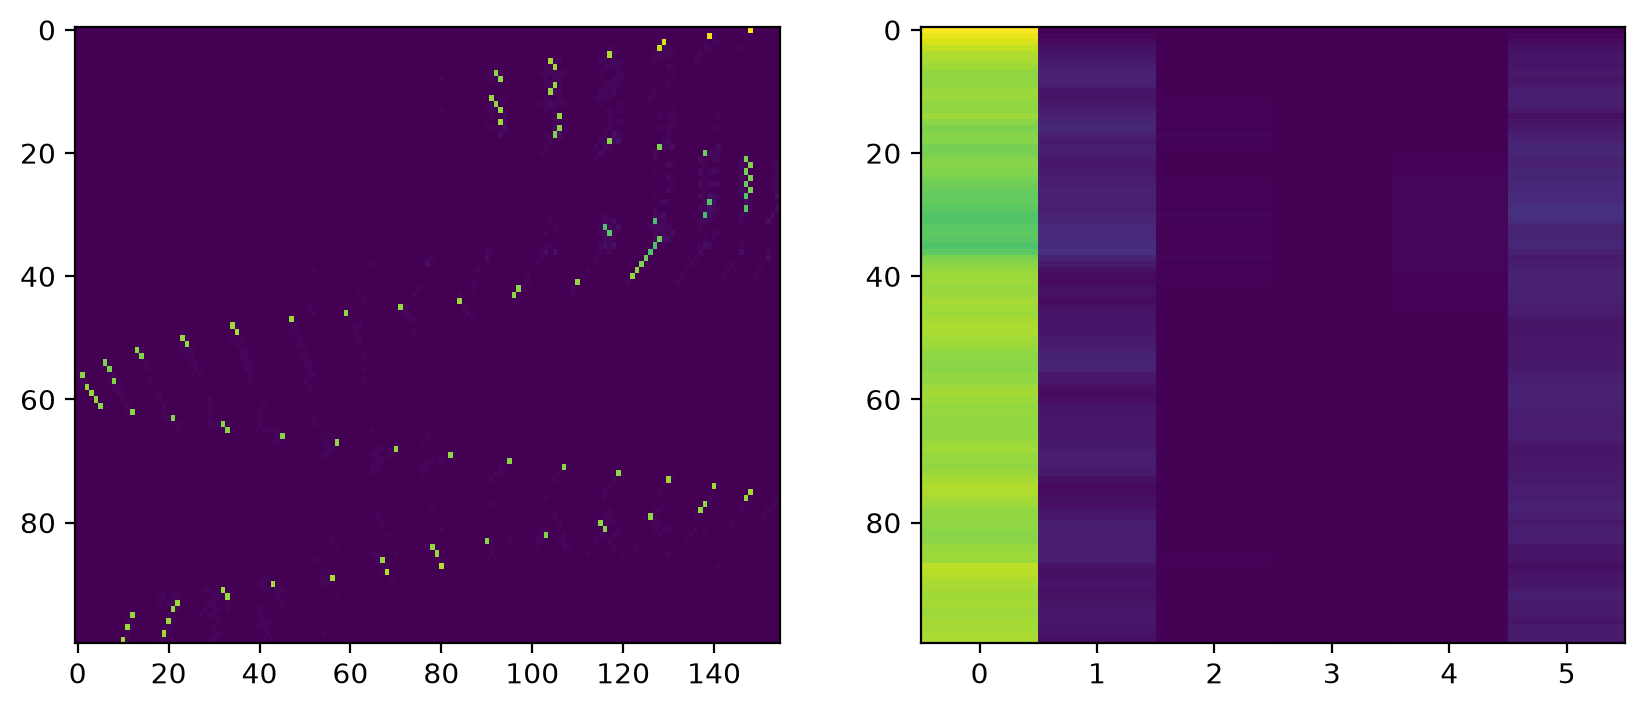

In [12]:
plt.figure(figsize=(10,4), dpi=200)
plt.subplot(1,2,1)
plt.imshow(pq_traj.sum(-1)[:100], aspect='auto')
plt.subplot(1,2,2)
plt.imshow(pq_traj.sum(1)[:100], aspect='auto')

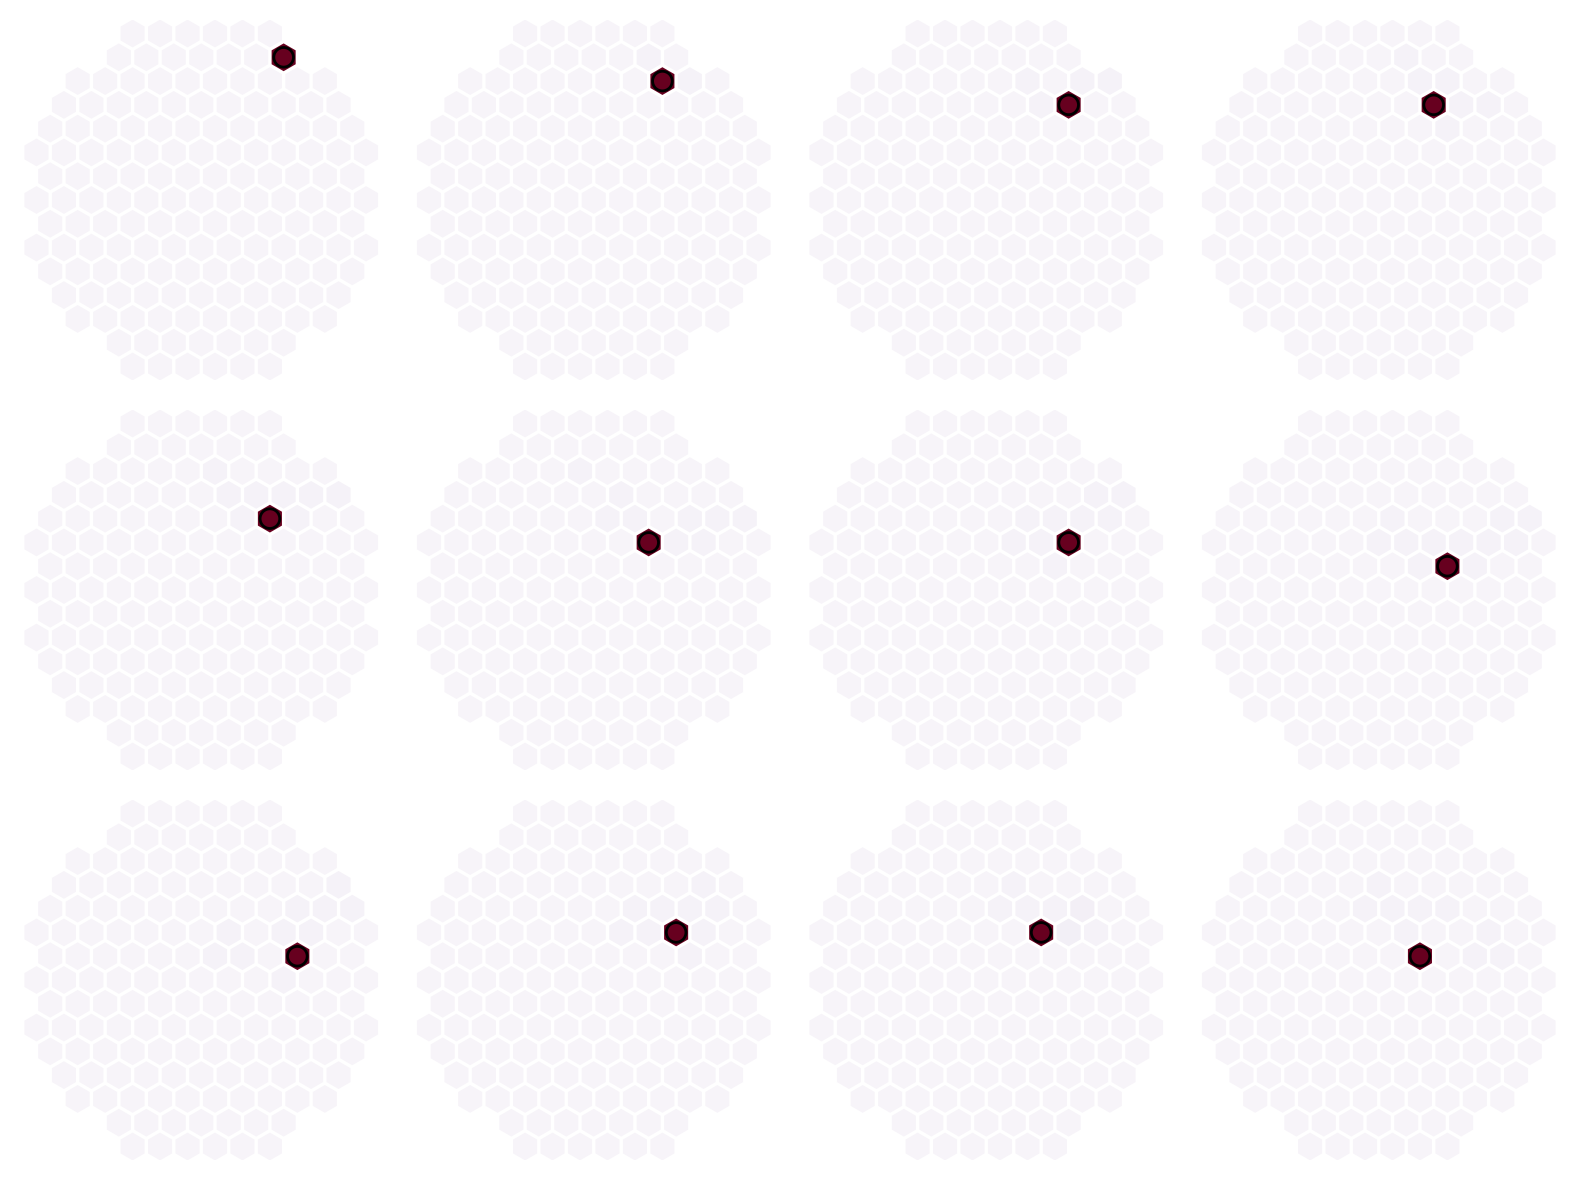

In [13]:
# prep
s_count = [Counter(s_traj)[x] for x in range(n_tiles)]
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# plot
plt.figure(figsize=(8,6), dpi=200)
i = 0
for t in range(0,12):
    i+=1
    plt.subplot(3,4,i)
    # plt.title(f'random walk ({seed}); top half occupied: {len(s_top)} tiles')
    # map
    s = s_traj[t]
    plt.scatter(hex_0_all, hex_1_all, c=pq_traj[t].sum(-1), cmap='PuRd', marker='h', s=100, vmin=0, edgecolor='none')
    plt.scatter([hex_0_all[s]], [hex_1_all[s]], s=50, edgecolor='k', facecolor='none')
    # for (x,y), s in xy_s_dict.items():
    #     plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')

    # setting
    plt.axis('off')
    plt.axis('equal')
plt.tight_layout()

### score map

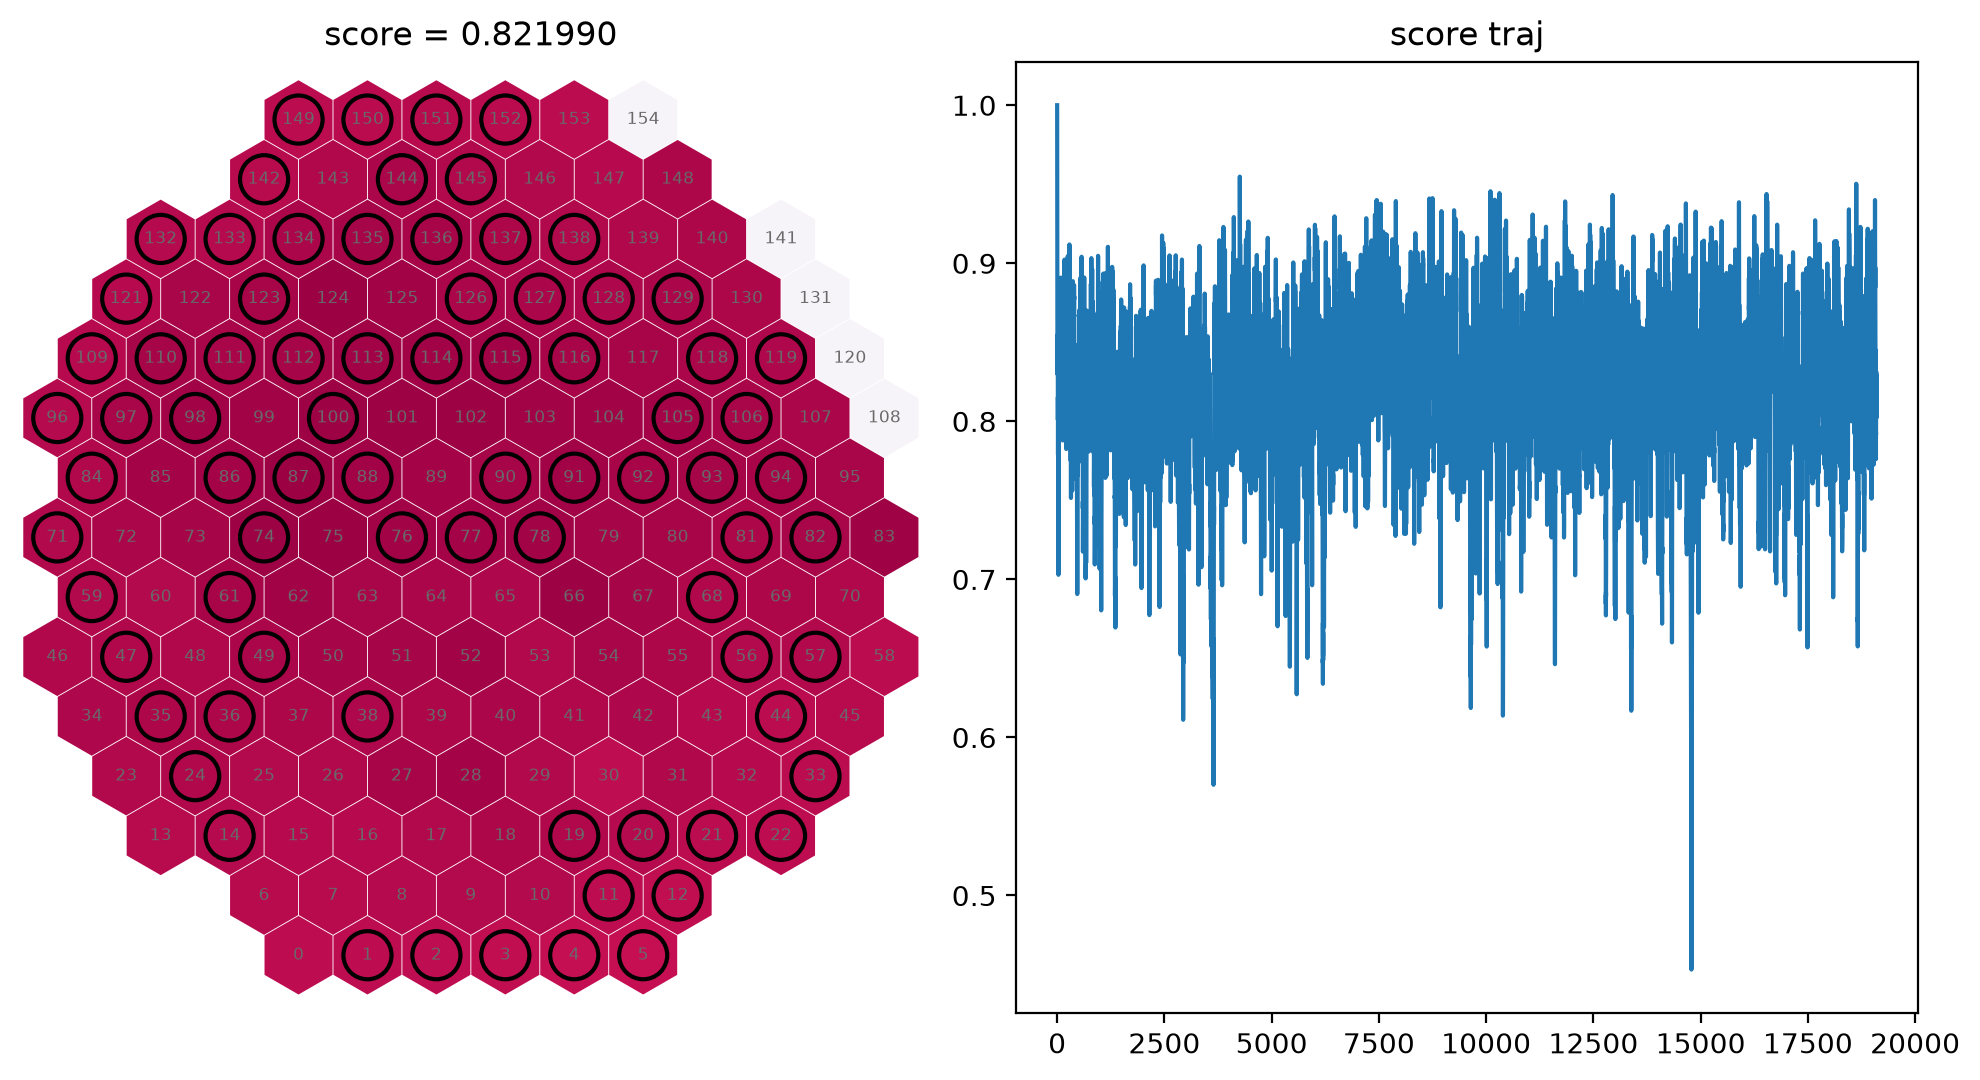

In [14]:
# prep
s_count = [Counter(s_traj)[x] for x in range(n_tiles)]
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# plot
plt.figure(figsize=(10,5.5), dpi=200)

plt.subplot(121)
plt.title(f'score = {score:.6f}')
plt.scatter(hex_0_all, hex_1_all, c=score_map, cmap='PuRd', marker='h', s=800, vmin=0, vmax=1, edgecolor='none')
# plot s_top in circular markers
plt.scatter(hex_0_all[s_top], hex_1_all[s_top], s=300, edgecolor='k', facecolor='none', marker='o', linewidth=1.5)
for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
# setting
plt.axis('off')
plt.axis('equal')
plt.tight_layout()

plt.subplot(122)
plt.title('score traj')
plt.plot(pq_traj.sum(-1).max(1))

plt.tight_layout()

## RUN: finding multiple lossless maps

## todo: just enum lossy map to simplify coding

In [16]:
# # load job
# type_id, seed, idx_pi = job_dict[job_id]
# s_traj, a_traj, occ_map, s_top = dat_traj_dict[type_id][seed]
# pi = pi_all[idx_pi]

### step 1) find maximum score with full map

In [17]:
# # MP functions
# sap_arr = get_sap_arr(pi, sas_dict, ringsize, n_tiles)
# def get_score_for_one_map(idx_masked):
#     # load
#     ring_arr_masked = get_ring_arr_masked(idx_masked, ring_arr, edge_id_arr)
    
#     # eval
#     p_traj = eval_one_map(ring_arr_masked, ring_arr, sap_arr, s_traj, a_traj)
#     score_map, score_traj = get_score_map(s_traj, p_traj)
#     score = score_map[s_top].mean()
#     return score, score_map.mean()

# # run
# score_max, _ = get_score_for_one_map([])
# score_max = np.floor(score_max * 1000) / 1000
# print(f'score_max = {score_max}')

### step 2) find multiple lossless (zero cost) maps

In [18]:
# def find_one_lossless_map(seed):
#     # load
#     n_segments = len(edge_id_arr)
    
#     # initialize
#     idx_masked = []
#     idx_remain = list(range(n_segments))
    
#     # iter
#     np.random.seed(seed)
#     n_failures = 0
#     for iter in range(n_segments):
#         if len(idx_remain) >= n_cand_per_iter:
#             idx_cand = np.random.choice(idx_remain, n_cand_per_iter)
#         else:
#             idx_cand = idx_remain
            
#         # iter until finding zero cost
#         is_zero_cost = False
#         idx_masked_cand = [idx_masked + [x] for x in idx_cand]
#         for jter, idx_ in enumerate(idx_masked_cand):
#             score_, _ = get_score_for_one_map(idx_)
#             if score_ >= score_max:
#                 idx_select = idx_[-1]
#                 # print(f'iter: {iter} hit at', jter, score_)
#                 is_zero_cost = True
#                 break
        
#         # append
#         if is_zero_cost:
#             idx_masked.append(idx_select)
#             idx_remain.remove(idx_select)
#         else:
#             n_failures += 1
#             # print('no hit, n_failures', n_failures)
#             if n_failures >= n_failures_to_stop:
#                 print(f'seed {seed} is stopping due to n_failures ={n_failures_to_stop}')
#                 break
        
#         # print
#         # print(f"iter {iter}: remove segm {idx_select}, score = {score_}")
        
#         if len(idx_remain)==0: break
#     return idx_masked

In [19]:
# # run (1h)
# with multiprocess.Pool() as p:
#     idx_masked_all = p.map(find_one_lossless_map, range(n_maps))

### step 3) sort maps with linear regression

In [20]:
# def sort_maps_with_linear_regression(idx_masked_all):
#     '''note: score is idential for all maps to numeric precision'''
#     # get score_map
#     n_removal_all = np.array([len(x) for x in idx_masked_all])
#     with multiprocess.Pool() as p:
#         score_all, score_map_all = zip(*p.map(get_score_for_one_map, idx_masked_all))
    
#     # linear regression
#     X = n_removal_all.reshape(-1, 1)
#     y = np.array(score_map_all)
#     y_pred = LinearRegression().fit(X, y).predict(X)
    
#     # sort by residual
#     idx_sort = np.argsort(y - y_pred)[::-1]
#     idx_masked_sort = np.array(idx_masked_all, dtype=object)[idx_sort]
#     return idx_masked_sort

In [21]:
# idx_masked_sort = sort_maps_with_linear_regression(idx_masked_all)

## PICKLE

In [22]:
# pickle.dump(idx_masked_sort, open(out_dir / f"lossless_maps_{job_id}", "wb"))

## RUN: finding multiple lossless maps

In [15]:
# job param
type_id, id_1, id_2 = 1, 3, 2
pi_level = 90

# mp
s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(type_id, id_1, id_2)]
pi = pi_all[pi_level]
def eval_one_map(map):
    # get pq_mask
    s_pq_mask_dict = get_s_pq_mask_dict_for_one_map(map, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
    
    # eval
    pq_traj = pq_prop_for_n_steps(s_traj, a_traj, T_dict, pi, s_pq_mask_dict, n_tiles, ringsize, sh_dz_arr)
    score_map, score = get_score_map(s_traj, pq_traj.sum(-1), s_top)
    score = np.around(score, 6)
    return score, score_map

In [24]:
# # load traj
# s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(1, 3, 2)]
# # s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(0, 3, -1)]
# # s_traj = np.array([37,50,63,76,89,102,115,127,128,129,130,131])
# # a_traj = np.array([-1,1,1,1,1,1,1,1,0,0,0,0])

# # load pi
# idx_pi = 90
# pi = pi_all[idx_pi]
# sap_arr = get_sap_arr(pi_all[100], sas_dict, ringsize, n_tiles) # pq_prop_v1

# # load map
# np.random.seed(42)
# map = np.random.permutation(n_edges)[:30]

# # prep: pq_mask from map
# pq_mask_unknown_dict = get_pq_mask_dict_for_unknown_edges(map, e_sh_arr, n_tiles, ringsize, n_edges)
# pq_mask_dict = get_pq_mask_dict(pq_mask_unknown_dict, pq_mask_amb_dict)

In [25]:
# load map
np.random.seed(42)
map = np.random.permutation(n_edges)[:80]

In [26]:
score, score_map = eval_one_map(map)
score

0.931664

(0.0, 289.95)

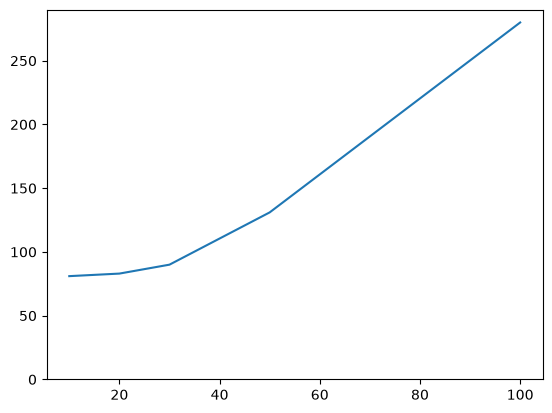

In [27]:
plt.plot([10,20,30,50,100], [81,83,90,131,280])
plt.ylim(0,None)

In [28]:
pq0 = np.zeros([n_tiles, ringsize])
pq0[s_traj[0], 0] = 1
pq_mask = s_pq_mask_dict[77]

In [29]:
# s_pq_mask_dict = dict()
# for s in range(n_tiles):
#     s_pq_mask = 1
#     for h in range(ringsize):
#         dz = sh_dz_arr[s, h]
#         s_pq_mask = s_pq_mask * pq_mask_dict[(dz, h)]
#     s_pq_mask_dict[s] = s_pq_mask

In [30]:
%%timeit
pq1 = pq0 * pq_mask
# pq1 / pq1.sum()

1.4 μs ± 4.06 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [31]:
%%timeit
collapse_pq_one_step(pq0, s_traj[0], s_pq_mask_dict, ringsize, sh_dz_arr)

3.26 μs ± 51.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [32]:
%%timeit
collapse_pq_one_step(pq0, s_traj[0], s_pq_mask_dict, ringsize, sh_dz_arr)

3.26 μs ± 13.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [16]:
# get score_max
score_max, score_map_max = eval_one_map(np.arange(n_edges))

# initialize
eid_removed = []
eid_remain = np.argsort(occ_map[e_sh_arr[:,0]]) # all edges sorted from least to most occupied (by tile occupancy)
score_iter, score_map_iter = [score_max], [score_map_max]

# iter
for iter in range(n_edges):
    # if len(eid_remain) >= n_cand_per_iter:
    #     eid_cand = np.random.choice(eid_remain, n_cand_per_iter)
    # else:
    #     eid_cand = eid_remain
    if score_iter[-1] == score_max:
        n_cand_per_iter = 100
    else:
        n_cand_per_iter = 100
    eid_cand = eid_remain[:n_cand_per_iter]
    
    # eval candidates
    eid_removed_cand = [eid_removed + [x] for x in eid_cand]
    eid_remain_cand = [eid_remain[eid_remain!=x] for x in eid_cand]
    with multiprocess.Pool() as p:
        score_cand, score_map_cand = zip(*p.map(eval_one_map, eid_remain_cand))
    
    # append top 
    idx_top = np.argmax(score_cand)
    eid_select = eid_cand[idx_top]
    eid_remain = eid_remain_cand[idx_top]
    # eid_select = eid_remain[np.random.choice(np.where(np.array(score_cand) == max(score_cand))[0])]
    # append
    eid_removed.append(eid_select)
    score_iter.append(score_cand[idx_top])
    score_map_iter.append(score_map_cand[idx_top])
    # eid_remain = eid_remain[eid_remain != eid_select]
    
    # print
    print(f"iter {iter}: remove edge {eid_select}, score = {score_iter[-1]}, n_cand_per_iter = {n_cand_per_iter}")
    
    if len(eid_remain)==0: break

iter 0: remove edge 928, score = 0.99979, n_cand_per_iter = 100
iter 1: remove edge 927, score = 0.99979, n_cand_per_iter = 100
iter 2: remove edge 925, score = 0.99979, n_cand_per_iter = 100
iter 3: remove edge 648, score = 0.99979, n_cand_per_iter = 100
iter 4: remove edge 649, score = 0.99979, n_cand_per_iter = 100
iter 5: remove edge 650, score = 0.99979, n_cand_per_iter = 100
iter 6: remove edge 651, score = 0.99979, n_cand_per_iter = 100
iter 7: remove edge 653, score = 0.99979, n_cand_per_iter = 100
iter 8: remove edge 851, score = 0.99979, n_cand_per_iter = 100
iter 9: remove edge 850, score = 0.99979, n_cand_per_iter = 100
iter 10: remove edge 791, score = 0.99979, n_cand_per_iter = 100
iter 11: remove edge 789, score = 0.99979, n_cand_per_iter = 100
iter 12: remove edge 847, score = 0.99979, n_cand_per_iter = 100
iter 13: remove edge 846, score = 0.99979, n_cand_per_iter = 100
iter 14: remove edge 786, score = 0.99979, n_cand_per_iter = 100
iter 15: remove edge 848, score = 0

Process ForkPoolWorker-17656:
Process ForkPoolWorker-17664:
Process ForkPoolWorker-17653:
Process ForkPoolWorker-17651:
Process ForkPoolWorker-17641:
Process ForkPoolWorker-17646:
Process ForkPoolWorker-17662:
Process ForkPoolWorker-17643:
Process ForkPoolWorker-17644:
Process ForkPoolWorker-17639:
Process ForkPoolWorker-17642:
Process ForkPoolWorker-17650:
Process ForkPoolWorker-17640:
Process ForkPoolWorker-17652:
Process ForkPoolWorker-17649:
Process ForkPoolWorker-17659:
Process ForkPoolWorker-17654:
Process ForkPoolWorker-17661:
Process ForkPoolWorker-17663:
Process ForkPoolWorker-17607:
Process ForkPoolWorker-17645:
Process ForkPoolWorker-17647:
Process ForkPoolWorker-17630:
Process ForkPoolWorker-17622:
Process ForkPoolWorker-17631:
Process ForkPoolWorker-17655:
Process ForkPoolWorker-17628:
Process ForkPoolWorker-17625:
Process ForkPoolWorker-17615:
Process ForkPoolWorker-17610:
Process ForkPoolWorker-17637:
Process ForkPoolWorker-17638:
Process ForkPoolWorker-17657:
Process Fo

KeyboardInterrupt: 

In [ ]:
dat_test = score_iter, score_map_iter, eid_removed
pickle.dump(dat_test, open(out_dir / "dat_test_2", "wb"))

In [ ]:
score_iter, score_map_iter, eid_removed = pickle.load(open(out_dir / "dat_test", "rb"))

In [74]:
np.unique(np.around(score_iter, 6))

array([0.99979])

(0.9, 1.1)

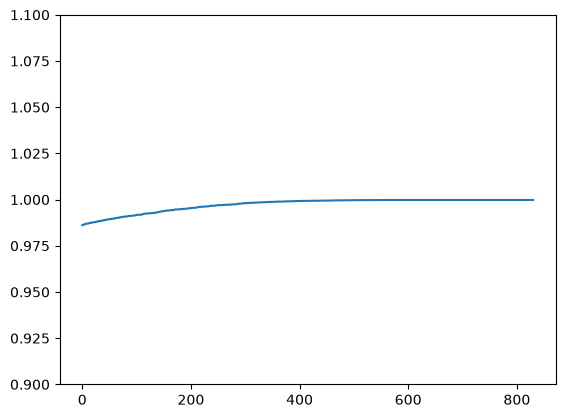

In [36]:
plt.plot(score_iter[::-1][100:1000])
plt.ylim(.9,1.1)

### step 1) find best lossy maps

In [ ]:
# MP functions
sap_arr = get_sap_arr(pi, sas_dict, ringsize, n_tiles)
def get_score_for_one_map(idx_masked):
    # load
    ring_arr_masked = get_ring_arr_masked(idx_masked, ring_arr, segm_idx_arr)
    
    # eval
    p_traj = eval_one_map(ring_arr_masked, ring_arr, sap_arr, s_traj, a_traj)
    score_map, score_traj = get_score_map(s_traj, p_traj)
    score = score_map[s_top].mean()
    return score

def find_one_lossy_map(seed=42):
    # load
    n_segments = len(segm_idx_arr)
    
    # initialize
    idx_masked = idx_masked_init.copy()
    idx_remain = [x for x in range(n_segments) if x not in idx_masked]
    
    # iter
    np.random.seed(seed)
    for iter in range(n_segments):
        if len(idx_remain) >= n_cand_per_iter:
            idx_cand = np.random.choice(idx_remain, n_cand_per_iter)
        else:
            idx_cand = idx_remain
        
        # eval candidates
        idx_masked_cand = [idx_masked + [x] for x in idx_cand]
        with multiprocess.Pool() as p:
            score_cand = p.map(get_score_for_one_map, idx_masked_cand)
        
        # append top 
        # idx_select = idx_cand[np.argmax(score_cand)]
        idx_select = idx_cand[np.random.choice(np.where(np.array(score_cand) == max(score_cand))[0])]
        idx_masked.append(idx_select)
        idx_remain.remove(idx_select)
        
        # print
        print(f"iter {iter}: remove segm {idx_select}, score = {max(score_cand)}")
        
        if len(idx_remain)==0: break
    return idx_masked

In [ ]:
# run (20m)
idx_masked = find_one_lossy_map()

iter 0: remove segm 784, score = 0.9850000170049673
iter 1: remove segm 71, score = 0.9850000170049673
iter 2: remove segm 377, score = 0.9850000170049673
iter 3: remove segm 75, score = 0.9850000170049673
iter 4: remove segm 917, score = 0.984996593609343
iter 5: remove segm 76, score = 0.984996593609343
iter 6: remove segm 348, score = 0.984996593609343
iter 7: remove segm 836, score = 0.984996593609343
iter 8: remove segm 533, score = 0.984995845720969
iter 9: remove segm 465, score = 0.984995845720969
iter 10: remove segm 263, score = 0.984995489665128
iter 11: remove segm 707, score = 0.9849937893843959
iter 12: remove segm 593, score = 0.9849922685465025
iter 13: remove segm 924, score = 0.9849896521930548
iter 14: remove segm 232, score = 0.9849871967947116
iter 15: remove segm 147, score = 0.9849871967947116
iter 16: remove segm 690, score = 0.9849863925056204
iter 17: remove segm 801, score = 0.9849831478866433
iter 18: remove segm 860, score = 0.9849786173830105
iter 19: remo

### step 2) eval lossy maps

In [ ]:
# eval (15s)
idx_masked_eval = [idx_masked[:x] for x in range(len(idx_masked)+1)]
with multiprocess.Pool() as p:
    score_eval = p.map(get_score_for_one_map, idx_masked_eval)
sensory_eval = [len(segm_idx_arr) - len(x) for x in idx_masked_eval]

## PICKLE

In [ ]:
dat_lossy_maps = idx_masked, sensory_eval, score_eval
pickle.dump(dat_lossy_maps, open(out_dir / f"dat_lossy_maps_{job_id}", "wb"))

## TEST

Text(0, 0.5, 'performance')

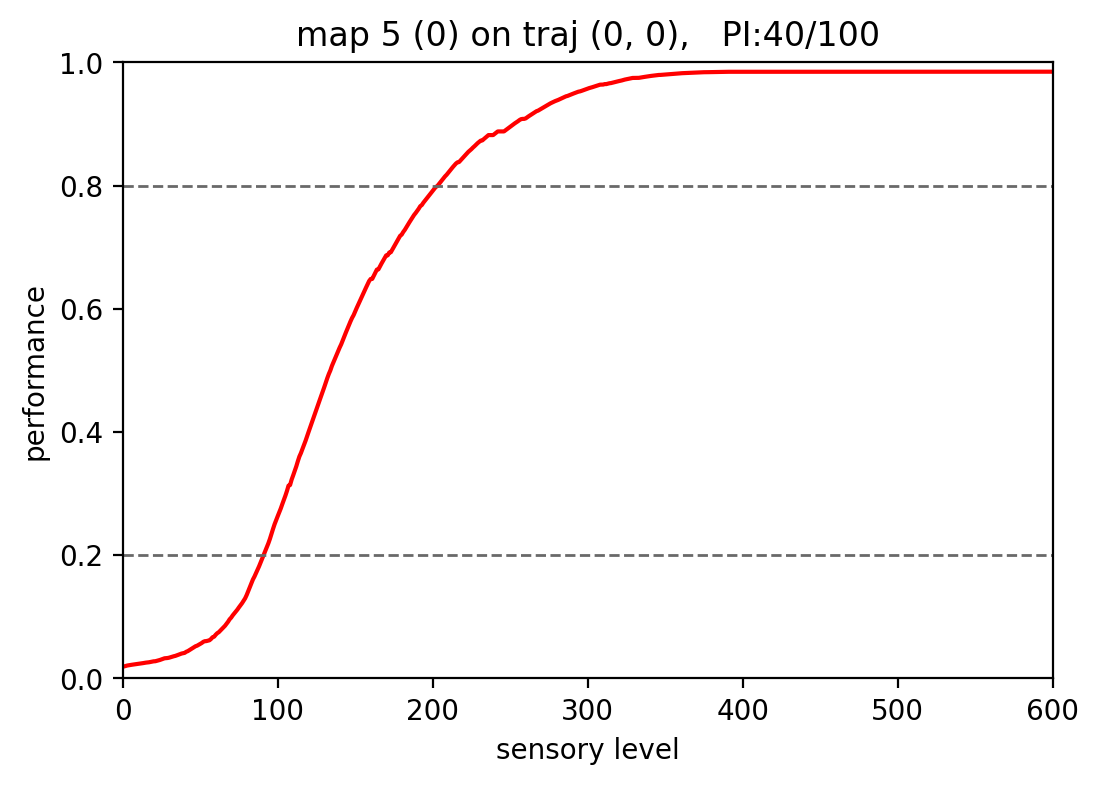

In [ ]:
# plot
plt.figure(figsize=(6,4), dpi=200)
plt.title(f"map {job_id_lossless} ({init_map_rank}) on traj {(type_id, seed)},   PI:{idx_pi}/100")

plt.plot(sensory_eval, score_eval, color='r')
#
plt.axhline(.8, color='dimgray', linestyle='--', lw=1)
plt.axhline(.2, color='dimgray', linestyle='--', lw=1)
plt.xlim([0,600])
plt.ylim([0,1])
# plt.legend()
plt.xlabel("sensory level")
plt.ylabel("performance")